# HydroRIVERS

The global river network from HydroSHEDS, as line geometry. It is what a flood model measures
distance to: a point's exposure depends on how far it sits from a channel big enough to carry a
flood.

## Provenance

These are the fields of the `RIVERS` declaration in
`climate_risk/data_functions/rivers_data_loader.py`, which is what `fetch` reads.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data_functions.rivers_data_loader import RIVERS

declared = {"publisher": "HydroSHEDS, World Wildlife Fund"} | dataclasses.asdict(RIVERS)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | HydroSHEDS, World Wildlife Fund |
| url | https://data.hydrosheds.org/file/HydroRIVERS/HydroRIVERS_v10_shp.zip |
| filename | HydroRIVERS_v10_shp.zip |
| license | HydroSHEDS License Agreement: free for scientific, educational and commercial use |
| citation | Lehner, B., Grill, G. (2013): Global river hydrography and network routing: baseline data and new approaches to study the world's large river systems. Hydrological Processes, 27(15), 2171-2186. https://doi.org/10.1002/hyp.9740 |
| retrieved | 2026-08-08 |

## Loading it

`load_rivers_data` unpacks the archive on a cold run and filters the network down before caching it.
The whole network is 8.5 million reaches, most of them streams too small to matter to a flood, so
the loader keeps the large ones. The cache directory is your choice, and this page uses one named
`data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt

import climate_risk as cr

from climate_risk.data_functions.rivers_data_loader import load_rivers_data
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

rivers = load_rivers_data(cache_dir)
world = cr.load_shapefile("world", cache_dir)

## What you get

A GeoDataFrame in EPSG:4326, one row per river reach, carrying HydroRIVERS' own attributes
unchanged. A reach is a segment between confluences, not a whole river, so the Mekong is thousands
of rows.

In [4]:
rivers[["HYRIV_ID", "NEXT_DOWN", "LENGTH_KM", "DIS_AV_CMS", "ORD_STRA", "ORD_FLOW"]].head()

,HYRIV_ID,NEXT_DOWN,LENGTH_KM,DIS_AV_CMS,ORD_STRA,ORD_FLOW
14055,10014056,10014177,7.25,103.52,6,4
14143,10014144,10014056,5.23,103.65,6,4
14176,10014177,10014495,6.00,103.41,6,4
14387,10014388,10014144,11.59,103.84,6,4
14388,10014389,10014388,6.27,104.00,6,4


## Units

| Column | Unit |
|---|---|
| `HYRIV_ID` | reach identifier, first digit the region |
| `NEXT_DOWN` | `HYRIV_ID` of the reach below, 0 at the outlet |
| `LENGTH_KM` | kilometers |
| `DIST_DN_KM`, `DIST_UP_KM` | kilometers along the network |
| `CATCH_SKM`, `UPLAND_SKM` | square kilometers |
| `DIS_AV_CMS` | cubic meters per second, long-term average |
| `ORD_STRA` | Strahler order, 1 at the headwaters and rising downstream |
| `ORD_FLOW` | discharge size class, 1 the largest |
| `geometry` | line, degrees in EPSG:4326 |

`ORD_FLOW` is the one the loader filters on, and it is a discharge class rather than a topological
order. Each class is a decade of cubic meters per second, counted down from the biggest.

## Coverage

The classes the filter keeps, with the discharge each one holds. Class 1 is every reach above
100,000 cubic meters per second, and the default cutoff stops after class 4.

In [5]:
classes = (
    rivers.groupby("ORD_FLOW")
    .agg(reaches=("HYRIV_ID", "size"), km=("LENGTH_KM", "sum"), least=("DIS_AV_CMS", "min"), most=("DIS_AV_CMS", "max"))
    .round(1)
)
classes

,reaches,km,least,most
ORD_FLOW,,,,
1,360,1319.20,126959.90,205603.70
2,8078,24802.70,10001.30,97534.00
3,53294,169470.60,1000.00,9999.80
4,211459,665082.60,100.00,999.90


## A plot

The network over mainland Southeast Asia, with the line weight following the discharge class. The
Mekong runs the length of the frame, and the Tonle Sap is the branch into the lake at its middle.

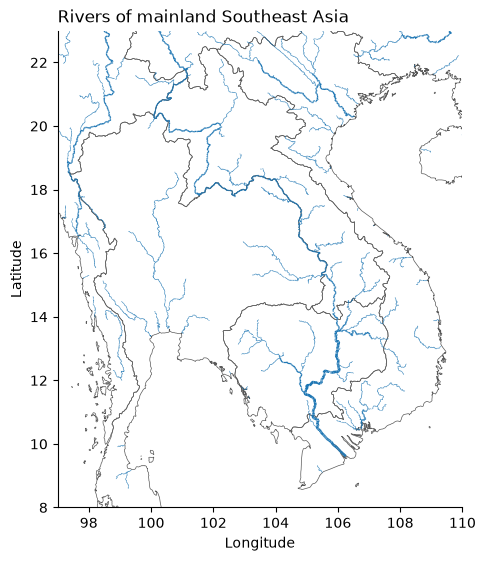

In [6]:
WEST, EAST, SOUTH, NORTH = 97.0, 110.0, 8.0, 23.0

region = rivers.cx[WEST:EAST, SOUTH:NORTH]

figure, axis = plt.subplots(figsize=(5.5, 5.5))
world.boundary.plot(ax=axis, color=PALETTE["divider"], lw=0.5)

# Drawn small to large, so a trunk river is not buried under the tributaries joining it. A class
# with no reaches in the window is skipped: plotting an empty frame has no bounds to set an aspect from.
for discharge_class, width in ((4, 0.4), (3, 0.9), (2, 1.8), (1, 2.6)):
    of_class = region[region["ORD_FLOW"] == discharge_class]
    if not of_class.empty:
        of_class.plot(ax=axis, color=PALETTE["primary"], lw=width)

axis.set_xlim(WEST, EAST)
axis.set_ylim(SOUTH, NORTH)
axis.set_title("Rivers of mainland Southeast Asia", loc="left")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
axis.grid(False)

plt.show()

## Gotchas

*`ORD_FLOW` is not a stream order.* HydroSHEDS documents it as a logarithmic discharge class, where
1 is every reach at or above 100,000 cubic meters per second and each class down is a factor of ten.
Strahler order is a separate column, `ORD_STRA`, and it runs the other way. The default cutoff keeps
classes 1 to 4, which is every reach at or above 100 cubic meters per second, and `include_medium`
adds class 5 down to 10.

*The cutoff is part of the cache key.* Loading with `include_medium=True` builds a second entry
rather than widening the first, so both filters can sit in one cache directory.

*A row is a reach, not a river.* Length, discharge and order are per segment. Summing `LENGTH_KM`
over a selection gives channel kilometers, and counting rows counts confluences more than it counts
rivers.

*The archive unpacks and stays unpacked.* The shapefile is extracted beside the zip and read from
there, so the cache holds both. The two together are about three gigabytes.

*Attribution is a license condition.* HydroSHEDS is free for scientific, educational and commercial
use, and the agreement requires the citation above to travel with anything derived from it.